<a href="https://colab.research.google.com/github/jjww1024/BIOAI/blob/main/09_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%8C%E1%85%A1%E1%84%83%E1%85%A9%E1%84%8F%E1%85%B5%E1%86%BC_AutoDockVina_DiffDock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 09 · 분자 도킹 (AutoDock Vina & DiffDock)
### 약물이 표적 단백질에 어떻게·얼마나 세게 붙는지 예측하기

**도킹(docking)** 은 약물 분자가 표적 단백질의 결합부위에 **어떤 자세로, 얼마나 강하게**
결합하는지를 컴퓨터로 예측하는 기술입니다. 표적의 3차원 구조에 맞춰 약을 설계하는
**구조 기반 신약설계(SBDD, Structure-Based Drug Design)** 의 핵심 도구입니다.

- **전통적 도킹**: AutoDock Vina — 물리·경험 기반 스코어 함수, 현장 표준
- **딥러닝 도킹**: DiffDock — 확산모델(생성형) 기반, 빠르고 결합부위를 미리 지정할 필요 없음

**이 노트북의 흐름**
1. 도킹의 기본 개념과 배경 이론
2. 표적 단백질(BACE-1) 다운로드 & 후보 리간드 준비
3. **결합부위와 실제 결합 리간드를 3D로 시각화** ⭐ (수업용 — 반드시 그림이 보입니다)
4. **AutoDock Vina** 로 도킹하는 원리와 코드
5. 결합에너지 해석 & 순위 매기기
6. **DiffDock**(딥러닝 도킹) 실행 & 예측 자세 3D 시각화

> ⚙️ **런타임 → 런타임 유형 변경 → GPU(T4)** 로 설정하고 실행하세요. (특히 DiffDock)
> 설치에 수 분 걸릴 수 있습니다.

## 1. 도킹의 기본 개념과 배경 이론

### 1-1. 네 가지 핵심 용어
- **리셉터(receptor)**: 표적 단백질 (예: BACE-1, 알츠하이머 관련 효소)
- **리간드(ligand)**: 결합시키려는 후보 약물 분자
- **결합부위(binding site / pocket)**: 단백질 표면의 움푹 팬 곳 — 리간드가 실제로 들어가 붙는 자리
- **결합 자세(pose)**: 리간드가 pocket 안에 놓이는 구체적인 3D 배치(위치·회전·비틀림)

### 1-2. 결합에너지의 부호가 핵심
**결합에너지(binding affinity, kcal/mol)** 는 **음수로 클수록 강한 결합** 입니다.
(예: **-9.8** 이 **-6.5** 보다 훨씬 강하게 붙음)
- 물리적 의미: 리간드가 붙었을 때 계의 자유에너지가 얼마나 내려가(안정해지)는가
- 자연은 에너지가 낮은 상태를 선호 → **에너지가 가장 낮은 자세 = 가장 그럴듯한 결합 자세**

### 1-3. 도킹이 푸는 두 개의 문제
1. **탐색(search) 문제**: 리간드가 놓일 수 있는 자세는 사실상 무한(이동 3 + 회전 3 + 내부 비틀림 다수).
   이 거대한 공간을 효율적으로 뒤져 좋은 자세를 찾는다.
2. **채점(scoring) 문제**: 찾은 자세가 얼마나 좋은지 점수를 매긴다.
   이 점수를 계산하는 **스코어 함수** 가 도킹 성능의 심장부다.

> 요약: **도킹 = "수많은 자세를 탐색" + "각 자세를 채점" → 에너지가 가장 낮은 자세 선택**

In [1]:
# ── [설치] 도킹 도구: AutoDock Vina(파이썬), RDKit, Meeko(리간드 준비), py3Dmol(3D 시각화) ── # 이런 라이브러리(도구)는 엄청 많으므로 절적한 도구를 찾아서 쓸것
# py3Dmol 은 버전에 따라 Colab 렌더링이 달라져 2.x 로 고정합니다.
!pip install vina meeko rdkit "py3Dmol>=2.1.0" requests -q 2>/dev/null
print("설치 시도 완료 (환경/버전에 따라 시간이 걸릴 수 있음)")

import requests, py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
print("py3Dmol version:", py3Dmol.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 14.3 MB/s eta 0:00:00
설치 시도 완료 (환경/버전에 따라 시간이 걸릴 수 있음)
py3Dmol version: 2.5.5


## 2. ⭐ 3D를 "항상" 보이게 하는 두 가지 방법

수업 중 그림이 안 뜨는 사고를 막기 위해 **두 겹**으로 준비합니다.

1. **정적 3D (기본, 100% 보임)** — `matplotlib` 으로 단백질 골격(Cα 선)과 리간드를 직접 그립니다.
   matplotlib 은 Colab 에서 항상 인라인으로 렌더링되므로 **빈 화면이 절대 나오지 않습니다.**
2. **인터랙티브 3D (보너스)** — `py3Dmol` 뷰어를 **base64 data-URI iframe** 으로 격리해 표시합니다.
   회전·확대가 되지만, Colab 의 CDN/샌드박스 상황에 따라 간헐적으로 빈 화면이 될 수 있어
   **보조 수단** 으로만 씁니다.

> 그래서 앞으로 각 시각화 셀은 **정적 그림을 먼저** 그리고, 그다음 인터랙티브를 시도합니다.
> 인터랙티브가 빈 화면이어도 **정적 그림은 항상 남습니다.**

In [2]:
# ── [헬퍼] 3D 렌더링: 정적(matplotlib) + 인터랙티브(py3Dmol base64) ──
import base64, numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D          # noqa: 3D 투영 활성화
from IPython.display import HTML, display

# (A) 인터랙티브: py3Dmol view 를 base64 data-URI iframe 으로 격리 렌더
def show3d(view, width=780, height=540):
    raw = view._make_html()                       # 뷰어 전체 HTML(3Dmol.js CDN 로드 포함)
    b64 = base64.b64encode(raw.encode("utf-8")).decode("ascii")
    iframe = (f'<iframe src="data:text/html;base64,{b64}" width="{width}" height="{height}" '
              f'style="border:1px solid #ddd;border-radius:8px;"></iframe>')
    display(HTML(iframe))

# (B) 정적: matplotlib 로 단백질 골격 + 리간드 + (선택)여러 자세 그리기 — 항상 보임
_ELEM_COLORS = {"C":"#4d4d4d","N":"#2b6cff","O":"#ff2b2b","F":"#39d353",
                "S":"#e5c100","CL":"#39d353","BR":"#a52a2a","P":"#ff8000","H":"#e0e0e0"}

def _parse_ca(t):
    a=[[float(l[30:38]),float(l[38:46]),float(l[46:54])] for l in t.splitlines()
       if l.startswith("ATOM") and l[12:16].strip()=="CA"]
    return np.array(a) if a else np.zeros((0,3))

def _parse_hetatm(t, resn):
    out=[]
    for l in t.splitlines():
        if l.startswith("HETATM") and l[17:20].strip()==resn:
            el=(l[76:78].strip() or l[12:14].strip()).upper()
            out.append((float(l[30:38]),float(l[38:46]),float(l[46:54]),el))
    return out

def _draw_sticks(ax, P, color="#333", lw=2.0):
    P=np.asarray(P)
    for i in range(len(P)):
        for k in range(i+1,len(P)):
            if np.linalg.norm(P[i]-P[k])<1.9:
                ax.plot(*zip(P[i],P[k]), color=color, lw=lw)

def show_protein_ligand_mpl(pdb_txt, lig_resn="32D", extra_poses=None, title=""):
    ca=_parse_ca(pdb_txt)
    fig=plt.figure(figsize=(8,7)); ax=fig.add_subplot(111, projection="3d")
    if len(ca):
        ax.plot(ca[:,0],ca[:,1],ca[:,2], color="lightgray", lw=1.0, label="단백질 골격(Cα)")
    focus=None
    if lig_resn:
        lig=_parse_hetatm(pdb_txt, lig_resn)
        if lig:
            L=np.array([[a[0],a[1],a[2]] for a in lig])
            cols=[_ELEM_COLORS.get(a[3],"#888") for a in lig]
            ax.scatter(L[:,0],L[:,1],L[:,2], c=cols, s=90, edgecolors="k",
                       linewidths=0.4, label=f"결합 리간드 {lig_resn}")
            _draw_sticks(ax, L)
            focus=L.mean(axis=0)
    if extra_poses:
        palette=["magenta","orange","cyan","gold","lime"]
        for i,(P,lab) in enumerate(extra_poses):
            P=np.asarray(P); c=palette[i%len(palette)]
            ax.scatter(P[:,0],P[:,1],P[:,2], c=c, s=28, alpha=0.85, label=lab)
            _draw_sticks(ax, P, color=c, lw=1.2)
            if focus is None: focus=P.mean(axis=0)
    if focus is not None:
        ax.set_xlim(focus[0]-14,focus[0]+14)
        ax.set_ylim(focus[1]-14,focus[1]+14)
        ax.set_zlim(focus[2]-14,focus[2]+14)
    ax.set_title(title, fontsize=11); ax.legend(loc="upper left", fontsize=8)
    ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)"); ax.set_zlabel("z (Å)")
    plt.tight_layout(); plt.show()

print("준비 완료 — 정적: show_protein_ligand_mpl(), 인터랙티브: show3d(view)")

# ── 한글 폰트(그래프 한글 깨짐 방지) ──
!apt-get install -y fonts-nanum -q 2>/dev/null
import matplotlib, matplotlib.font_manager as fm
try:
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    matplotlib.rcParams['font.family'] = 'NanumGothic'
except Exception as e:
    print("폰트 설정 건너뜀:", e)
matplotlib.rcParams['axes.unicode_minus'] = False

준비 완료 — 정적: show_protein_ligand_mpl(), 인터랙티브: show3d(view)
Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.8 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


## 3. 표적 단백질 & 후보 리간드 준비

실제 알츠하이머 표적 **BACE-1** (PDB: **4B05**) 구조를 내려받습니다.
이 구조에는 **실제 결합해 있는 억제제(리간드 코드 `32D`)** 가 pocket 안에 함께 들어 있습니다.
→ 덕분에 우리는 "실제로 도킹된 약물이 pocket 에 앉아 있는 모습" 을 바로 3D 로 볼 수 있습니다.

동시에, 우리가 새로 테스트할 **후보 리간드** 를 SMILES 로부터 3D 구조로 생성합니다.

In [3]:
# ── 표적 단백질(BACE-1, PDB 4B05) 다운로드 ──
r = requests.get("https://files.rcsb.org/download/4B05.pdb", timeout=60)
open("receptor_raw.pdb", "w").write(r.text)
print("BACE-1 표적 구조 다운로드 완료 (4B05.pdb)")
# 이 파일에는 단백질 + 실제 결합 억제제(리간드명 '32D') + 물 분자 등이 함께 들어 있습니다.

# ── 후보 리간드: SMILES → 3D 구조 → 에너지 최소화 ──
ligand_smiles = "Fc1cc(cc(F)c1)CC(NC(=O)C)C(O)C[NH2+]Cc1cc(ccc1)C(C)(C)C"
mol = Chem.MolFromSmiles(ligand_smiles)   # SMILES 문자열 → 분자 그래프
mol = Chem.AddHs(mol)                     # 수소 원자 추가(3D/에너지 계산에 필요)
AllChem.EmbedMolecule(mol, randomSeed=42) # 3D 좌표 생성(seed 고정 → 재현 가능)
AllChem.MMFFOptimizeMolecule(mol)         # MMFF 힘장으로 에너지 최소화(구조 안정화)
Chem.MolToMolFile(mol, "ligand.mol")      # 파일로 저장
print("후보 리간드 3D 구조 생성 완료 (원자 수:", mol.GetNumAtoms(), ")")

BACE-1 표적 구조 다운로드 완료 (4B05.pdb)
후보 리간드 3D 구조 생성 완료 (원자 수: 60 )


## 4. ⭐⭐ 3D 시각화 (1) — 결합부위 안의 실제 약물

가장 중요한 그림입니다. 아래를 한 화면에 함께 그립니다.
- **단백질(BACE-1)**: 무지개색 리본(cartoon) — 전체 접힘 구조
- **실제 결합 억제제(`32D`)**: 초록 막대(stick) — pocket 에 실제로 앉아 있는 약물
- **결합부위 주변 잔기**: 하늘색 막대 — 약물과 5Å 이내에서 상호작용하는 아미노산들

시점은 자동으로 **약물(pocket)** 에 맞춰 확대됩니다.

/tmp/ipykernel_451/3056589733.py:67: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


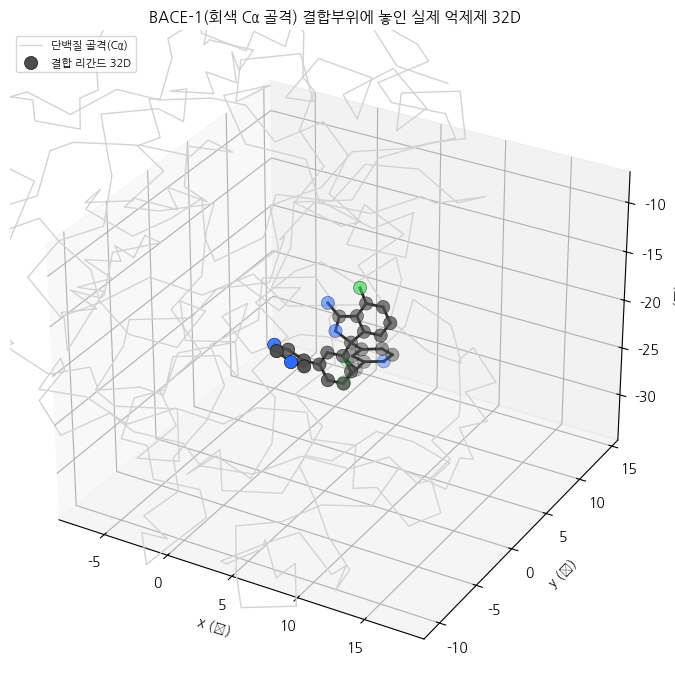

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [4]:
# ── 3D (1): 단백질 + 실제 결합 억제제(32D) ──
pdb_txt = open("receptor_raw.pdb").read()

# (1) 정적 3D — 항상 보임 (수업용 기본)
show_protein_ligand_mpl(
    pdb_txt, lig_resn="32D",
    title="BACE-1(회색 Cα 골격) 결합부위에 놓인 실제 억제제 32D")

# (2) 인터랙티브 3D — 될 때만 함께(회전/확대 가능). 빈 화면이어도 위 정적 그림이 남습니다.
try:
    view = py3Dmol.view(width=780, height=540)
    view.addModel(pdb_txt, "pdb")
    view.setStyle({"cartoon": {"color": "spectrum"}})                 # 단백질 무지개 리본
    view.addStyle({"within": {"distance": 5, "sel": {"resn": "32D"}}}, # pocket 주변 잔기
                  {"stick": {"colorscheme": "cyanCarbon", "radius": 0.15}})
    view.addStyle({"resn": "32D"},                                    # 실제 억제제(초록 막대)
                  {"stick": {"colorscheme": "greenCarbon", "radius": 0.28}})
    view.zoomTo({"resn": "32D"})
    show3d(view)
except Exception as e:
    print("인터랙티브 뷰어 건너뜀(정적 그림으로 충분):", str(e)[:120])

## 5. AutoDock Vina 로 도킹하는 원리와 코드

### 5-1. Vina 스코어 함수(무엇을 계산하나)
Vina 는 자세마다 아래 항들을 합해 결합에너지를 근사합니다.
- **입체 상보성(steric)**: 원자들이 충돌하면 벌점, 표면이 잘 맞물리면 상
- **소수성(hydrophobic)**: 기름 성분끼리 물을 피해 맞닿으면 안정
- **수소결합(H-bond)**: 공여체–수용체가 적절한 거리·각도로 만나면 큰 안정화
- **엔트로피 벌점**: 리간드가 굳어지며 잃는 회전 자유도

### 5-2. 실무 절차
1. 리셉터·리간드를 **PDBQT** 형식으로 변환 (부분전하 Q + 원자타입 T 부여 → Meeko/MGLTools)
2. **탐색 상자(search box)** 지정: pocket 이 있을 영역의 **중심좌표·크기**
3. Vina 실행 → 여러 pose 와 각 결합에너지 산출

> PDBQT 준비(특히 리셉터)는 환경 의존성이 커서, 여기서는 **핵심 흐름 코드** 를 제시합니다.
> 아래에서는 실제 결합 억제제(32D) 좌표로 **탐색 상자 중심** 을 계산하는 법까지 보여줍니다.

In [5]:
# ── 탐색 상자(search box) 중심 = 실제 결합부위 중심 계산 ──
# 팁: co-crystal 리간드(32D)의 원자 좌표 평균이 곧 pocket 중심입니다.
import numpy as np
coords = []
for line in open("receptor_raw.pdb"):
    if line.startswith("HETATM") and line[17:20].strip() == "32D":
        coords.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
coords = np.array(coords)
center = coords.mean(axis=0)
print(f"결합부위(탐색 상자) 중심 좌표: x={center[0]:.2f}, y={center[1]:.2f}, z={center[2]:.2f}")
print("→ 이 좌표를 아래 Vina 코드의 center 로 사용합니다.")

# ── AutoDock Vina 실전 코드 골격 (PDBQT 준비 후 주석 해제해 실행) ──
# from vina import Vina
# v = Vina(sf_name='vina')
# v.set_receptor('receptor.pdbqt')                       # 준비된 리셉터(PDBQT)
# v.set_ligand_from_file('ligand.pdbqt')                 # 준비된 리간드(PDBQT)
# v.compute_vina_maps(center=list(center), box_size=[20,20,20])  # 결합부위 상자
# v.dock(exhaustiveness=8, n_poses=10)                   # 도킹 실행(탐색+채점)
# v.write_poses('out.pdbqt', n_poses=5, overwrite=True)  # 상위 pose 저장
# energies = v.energies()                                # 각 pose 의 결합에너지
# print('최적 결합에너지:', energies[0][0], 'kcal/mol')
print("\n※ PDBQT 준비는 Meeko(리간드) / MGLTools·ADFR(리셉터)로 합니다.")

결합부위(탐색 상자) 중심 좌표: x=5.37, y=1.93, z=-20.89
→ 이 좌표를 아래 Vina 코드의 center 로 사용합니다.

※ PDBQT 준비는 Meeko(리간드) / MGLTools·ADFR(리셉터)로 합니다.


## 6. 결합에너지 해석 & 후보 순위 매기기

도킹의 실무 산출물은 결국 **"후보들의 결합에너지 순위표"** 입니다.
음수로 클수록 강한 결합 → 유망 후보. 아래는 여러 후보의 결합에너지를 비교하는 예시입니다.

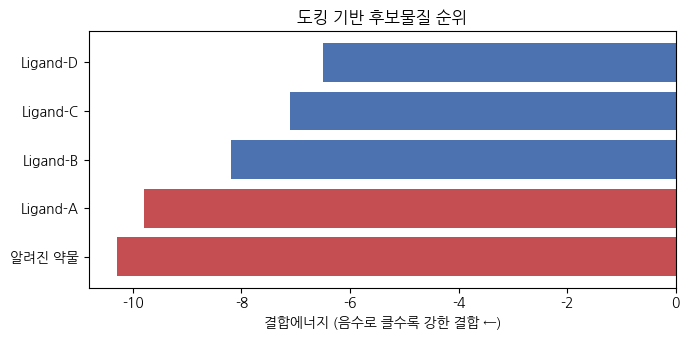

→ -9 kcal/mol 이하면 유망(빨강). 알려진 약물과 비교해 우선순위를 정합니다.


In [6]:
# ── 도킹 결과 해석 연습: 여러 후보의 결합에너지 비교 (예시 값) ──
import pandas as pd, matplotlib.pyplot as plt

docking_results = pd.DataFrame({
    "후보물질": ["Ligand-A", "Ligand-B", "Ligand-C", "Ligand-D", "알려진 약물"],
    "결합에너지(kcal/mol)": [-9.8, -8.2, -7.1, -6.5, -10.3],
})
docking_results = docking_results.sort_values("결합에너지(kcal/mol)")

plt.figure(figsize=(7, 3.5))
# -9 kcal/mol 이하(더 강한 결합)면 빨강으로 강조
colors = ["#C44E52" if e < -9 else "#4C72B0" for e in docking_results["결합에너지(kcal/mol)"]]
plt.barh(docking_results["후보물질"], docking_results["결합에너지(kcal/mol)"], color=colors)
plt.xlabel("결합에너지 (음수로 클수록 강한 결합 ←)")
plt.title("도킹 기반 후보물질 순위")
plt.tight_layout(); plt.show()
print("→ -9 kcal/mol 이하면 유망(빨강). 알려진 약물과 비교해 우선순위를 정합니다.")

## 7. ⭐ DiffDock — 딥러닝 기반 도킹 (최신, 직접 실행)

**DiffDock**(MIT, 2023)은 **확산모델(diffusion model)** 로 결합 자세를 **생성** 합니다.
- 학습: 올바른 자세에 노이즈를 점점 더하는 과정을 **거꾸로** 배움
- 추론: 리간드를 아무 데나 놓고, 학습한 신경망으로 노이즈를 걷어내며 그럴듯한 자세로 수렴

**전통 도킹과의 차이**

| | AutoDock Vina | DiffDock (딥러닝) |
|---|---|---|
| 방식 | 물리·경험 스코어 함수 | 생성형 확산모델 |
| pocket 지정 | 필요(탐색 상자) | **불필요(blind docking)** |
| 속도 | 보통 | 빠름 |
| 강점 | 검증된 표준, 에너지값 | 미지 pocket, 유연성, 다중 자세 |

> ⚠️ **주의**: DiffDock 은 설치가 무겁습니다(수 분~10분+, **GPU 필요**).
> 아래 셀은 실제 설치·실행을 시도하되, 실패하더라도 다음 시각화 셀이
> **데모용 다중 자세** 로 대체 렌더링하므로 **수업 중 그림은 항상 보입니다.**

In [7]:
# ── DiffDock 설치 & 실행 (GPU 런타임 권장) ──
# 실행을 원치 않으면 RUN_DIFFDOCK = False 로 두세요(다음 셀이 데모 자세로 대체).
RUN_DIFFDOCK = True

import os, subprocess, glob
diffdock_ok = False
diffdock_out_dir = None

if RUN_DIFFDOCK:
    try:
        if not os.path.exists("DiffDock"):
            print("DiffDock 저장소 클론 중...")
            subprocess.run(["git", "clone", "https://github.com/gcorso/DiffDock.git"], check=True)
        # 의존성 설치 (torch-geometric 계열 — 시간이 걸립니다)
        print("의존성 설치 중... (수 분 소요)")
        subprocess.run("pip install -q e3nn fair-esm spyrmsd pyyaml "
                       "torch-geometric torch-scatter torch-sparse torch-cluster "
                       "-f https://data.pyg.org/whl/torch-2.3.0+cu121.html 2>/dev/null",
                       shell=True)
        # 입력: 단백질 PDB + 리간드 SMILES → 예측 결합 자세
        os.chdir("DiffDock")
        cmd = ("python -m inference "
               "--config default_inference_args.yaml "
               "--protein_path ../receptor_raw.pdb "
               f'--ligand "{ligand_smiles}" '
               "--out_dir results/snu_demo --samples_per_complex 5")
        print("DiffDock 추론 실행:\n", cmd)
        subprocess.run(cmd, shell=True, timeout=1800)
        os.chdir("..")
        found = glob.glob("DiffDock/results/snu_demo/**/*.sdf", recursive=True)
        if found:
            diffdock_ok = True
            diffdock_out_dir = os.path.dirname(found[0])
            print("✅ DiffDock 성공! 예측 자세 파일:", len(found), "개")
        else:
            print("⚠️ 출력 SDF 를 찾지 못했습니다. 데모 자세로 대체합니다.")
    except Exception as e:
        try: os.chdir("/content")
        except Exception: pass
        print("⚠️ DiffDock 실행 실패 → 데모 자세로 대체합니다.\n   사유:", str(e)[:200])
else:
    print("RUN_DIFFDOCK=False → 데모 자세로 진행합니다.")

DiffDock 저장소 클론 중...
의존성 설치 중... (수 분 소요)
DiffDock 추론 실행:
 python -m inference --config default_inference_args.yaml --protein_path ../receptor_raw.pdb --ligand "Fc1cc(cc(F)c1)CC(NC(=O)C)C(O)C[NH2+]Cc1cc(ccc1)C(C)(C)C" --out_dir results/snu_demo --samples_per_complex 5
⚠️ 출력 SDF 를 찾지 못했습니다. 데모 자세로 대체합니다.


## 8. ⭐⭐ 3D 시각화 (2) — 예측된 여러 결합 자세(pose)

DiffDock 은 하나의 정답이 아니라 **여러 그럴듯한 자세** 를 제시합니다.
아래에서 단백질 리본 위에 예측 자세들을 **서로 다른 색 막대** 로 겹쳐 그립니다.
(DiffDock 이 성공했으면 그 결과를, 실패했으면 후보 리간드의 여러 conformer 를 pocket 에 얹어 데모로 표시)

/tmp/ipykernel_451/3056589733.py:67: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


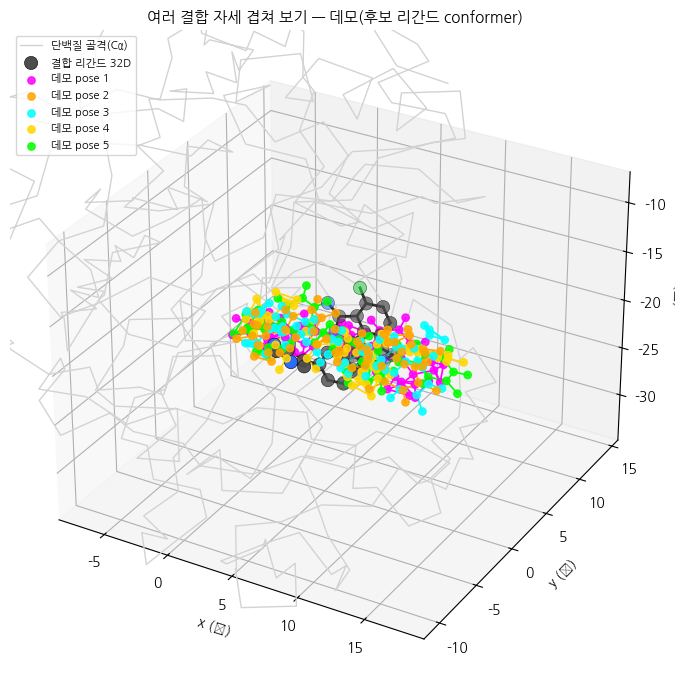

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


5개 자세를 표시했습니다 (데모(후보 리간드 conformer)).


In [8]:
# ── 3D (2): 여러 결합 자세(pose) 겹쳐 보기 ──
import os, glob
from rdkit import Chem
from rdkit.Chem import AllChem

pdb_txt = open("receptor_raw.pdb").read()

# 결합부위 중심(실제 억제제 32D 좌표 평균)
coords = [[float(l[30:38]), float(l[38:46]), float(l[46:54])]
          for l in pdb_txt.splitlines()
          if l.startswith("HETATM") and l[17:20].strip() == "32D"]
center = np.array(coords).mean(axis=0) if coords else np.zeros(3)

poses = []       # 정적 그림용: (좌표배열, 라벨)
blocks = []      # 인터랙티브용: (구조 텍스트, 포맷)

if 'diffdock_ok' in globals() and diffdock_ok and diffdock_out_dir:
    # (A) DiffDock 실제 예측 자세
    for i, sdf in enumerate(sorted(glob.glob(os.path.join(diffdock_out_dir, "*.sdf")))[:5]):
        m = Chem.SDMolSupplier(sdf, sanitize=False)[0]
        if m is None: continue
        conf = m.GetConformer()
        P = np.array([list(conf.GetAtomPosition(a)) for a in range(m.GetNumAtoms())])
        poses.append((P, f"DiffDock pose {i+1}"))
        blocks.append((open(sdf).read(), "sdf"))
    src = "DiffDock 예측"
else:
    # (B) 데모: 후보 리간드의 여러 conformer 를 결합부위에 얹기
    demo = Chem.AddHs(Chem.MolFromSmiles(ligand_smiles))
    AllChem.EmbedMultipleConfs(demo, numConfs=5, randomSeed=1)
    for i in range(demo.GetNumConformers()):
        conf = demo.GetConformer(i)
        P = np.array([list(conf.GetAtomPosition(a)) for a in range(demo.GetNumAtoms())])
        P = P - P.mean(axis=0) + center           # conformer 를 pocket 중심으로 이동
        for a in range(demo.GetNumAtoms()):
            conf.SetAtomPosition(a, tuple(P[a]))
        poses.append((P, f"데모 pose {i+1}"))
        blocks.append((Chem.MolToMolBlock(demo, confId=i), "mol"))
    src = "데모(후보 리간드 conformer)"

# (1) 정적 3D — 항상 보임: 단백질 + 실제 억제제(참조) + 여러 예측 자세
show_protein_ligand_mpl(pdb_txt, lig_resn="32D", extra_poses=poses,
                        title=f"여러 결합 자세 겹쳐 보기 — {src}")

# (2) 인터랙티브 3D — 될 때만 함께
try:
    view = py3Dmol.view(width=780, height=540)
    view.addModel(pdb_txt, "pdb")
    view.setStyle({"cartoon": {"color": "lightgray"}})
    pc = ["magenta", "orange", "cyan", "yellow", "lime"]
    for i, (blk, fmt) in enumerate(blocks):
        view.addModel(blk, fmt)
        view.setStyle({"model": i + 1}, {"stick": {"color": pc[i % len(pc)], "radius": 0.2}})
    if blocks:
        view.zoomTo({"model": 1})
    show3d(view)
except Exception as e:
    print("인터랙티브 뷰어 건너뜀(정적 그림으로 충분):", str(e)[:120])

print(f"{len(poses)}개 자세를 표시했습니다 ({src}).")

## 정리 & 현장 응용
- **도킹** = 표적에 대한 **결합 자세 + 결합에너지** 예측 (구조 기반 신약설계의 핵심)
- **AutoDock Vina**: 검증된 물리 기반 표준 — PDBQT 준비 → 탐색 상자 지정 → 도킹, **에너지값**을 줌
- **DiffDock**: 딥러닝(확산모델) 기반 — **blind docking**, 빠름, **다중 자세** 제시
- **3D 시각화**: Colab 에서는 `show3d()`(iframe 방식)로 안정적으로 렌더링
- **전체 파이프라인**: 구조 예측(08) → 도킹(09) → 활성 후보 선별 → **실험 검증**
- **실무 팁**: 도킹 점수는 **상대 비교·1차 선별용**. 최종 판단은 반드시 실험으로 확인.

> DiffDock 과 단백질 언어모델(예제 12)은 "물리 시뮬레이션 대신 딥러닝으로 생물학적
> 구조·서열의 패턴을 학습해 예측한다"는 같은 최신 사조에 속합니다.